# Preprocessing Steps for Video Super-Resolution

This notebook documents and executes the key preprocessing steps implemented in Phase 1 of the **Adaptive Video Super-Resolution Framework**.

### Step 1: Environment Setup & File Validation
We start by importing standard libraries: OpenCV (`cv2`) for image manipulations, and NumPy (`np`) for matrix math. We resolve the relative path to locate the input video (`input_trimmed.mp4`) in the project root folder.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Locate the input video relative to the notebook directory (two folders up in project root)
video_path = '../../input_trimmed.mp4'
if not os.path.exists(video_path):
    # Fallback to local path if already executed in root
    video_path = 'input_trimmed.mp4'

print(f"Resolved video path: {os.path.abspath(video_path)}")
print(f"File exists:         {os.path.exists(video_path)}")

Resolved video path: D:\Full Stack\AdaptiveSR\input_trimmed.mp4
File exists:         True


### Step 2: Video Metadata Extraction
Using OpenCV's `VideoCapture` API, we retrieve crucial stream metadata: width, height, frame rate (FPS), and total frame count. These parameters are used to dynamically initialize the output encoder dimensions and calculate durations.

In [2]:
# Extract Video Metadata
cap = cv2.VideoCapture(video_path)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = count / fps
cap.release()

print(f"Video Dimensions: {w} x {h}")
print(f"FPS:              {fps}")
print(f"Total Frames:     {count}")
print(f"Duration:         {duration:.2f} seconds")

Video Dimensions: 640 x 480
FPS:              30.0
Total Frames:     30
Duration:         1.00 seconds


### Step 3: Color Space Conversion & Downscaling Simulation
OpenCV decodes frames in BGR format by default. Since PyTorch neural models expect RGB format scaled to `[0.0, 1.0]`, we convert the color space. We also simulate a low-resolution (LR) input frame by downscaling the source using bilinear/area interpolation (`cv2.INTER_AREA`), which models the pipeline input scenario.

In [3]:
# Color Space Conversion & Downscaling Simulation
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    # Convert BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print(f"Original shape (BGR): {frame.shape}")
    print(f"RGB converted shape:  {frame_rgb.shape}")
    
    # Simulate Downscaling (Scale factor = 2x, downscaling 1080p to 540p or 960p to 480p)
    h_orig, w_orig = frame.shape[:2]
    frame_lr = cv2.resize(frame, (w_orig // 2, h_orig // 2), interpolation=cv2.INTER_AREA)
    print(f"LR Sim shape:         {frame_lr.shape}")
else:
    print("Error: Failed to read first frame.")

Original shape (BGR): (480, 640, 3)
RGB converted shape:  (480, 640, 3)
LR Sim shape:         (240, 320, 3)


### Step 4: Visualizing Original vs. Downscaled (Simulated LR) Frame
Here we display the original input frame next to the simulated low-resolution frame using `matplotlib` to visually inspect scaling differences.

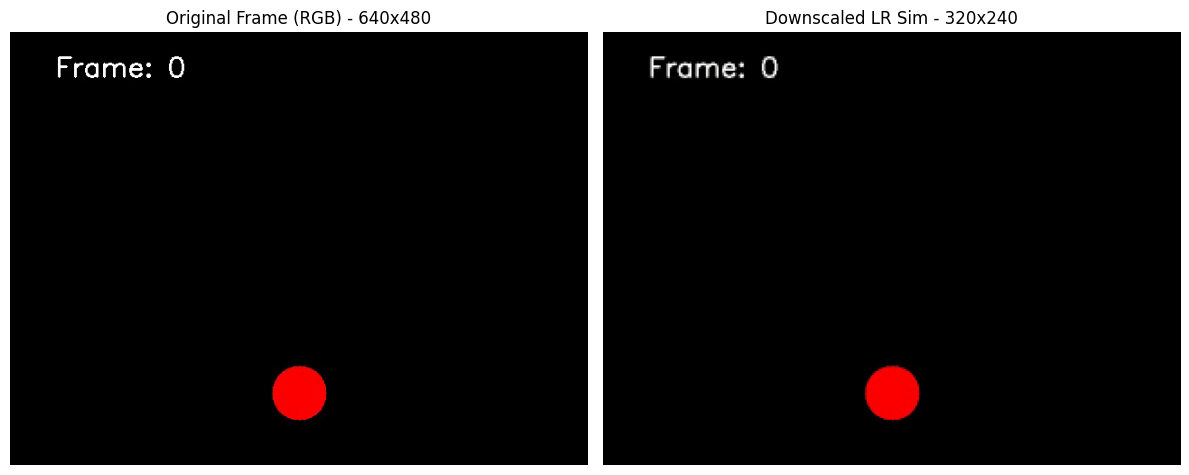

In [4]:
if ret:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title(f"Original Frame (RGB) - {w_orig}x{h_orig}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    frame_lr_rgb = cv2.cvtColor(frame_lr, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_lr_rgb)
    plt.title(f"Downscaled LR Sim - {frame_lr.shape[1]}x{frame_lr.shape[0]}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

### Step 5: Visual Feature & Complexity Extraction
To drive our dynamic routing decision logic, we extract key visual metrics on the grayscale frame:
1.  **Texture variance**: Computed using the variance of the Laplacian filter (`cv2.Laplacian`), mapping frame details and focus.
2.  **Edge Density**: Extracted using the Canny edge detector (`cv2.Canny`), measuring spatial complexity.

In [5]:
# Compute Scene Analyzer Features (Edges & Texture Complexity)
if ret:
    # Convert to grayscale for feature extraction
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Texture details (Laplacian variance)
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    # Edge density (Canny edge ratio)
    canny = cv2.Canny(gray, 50, 150)
    edge_ratio = np.sum(canny > 0) / canny.size
    
    print(f"Laplacian Texture Variance: {lap_var:.2f}")
    print(f"Canny Edge Density Ratio:   {edge_ratio * 100:.4f}%")

Laplacian Texture Variance: 426.12
Canny Edge Density Ratio:   0.2650%


### Step 6: Visualizing Canny Edges
We plot the extracted Canny edge detection mask to illustrate the edges that feed the complexity scoring weights.

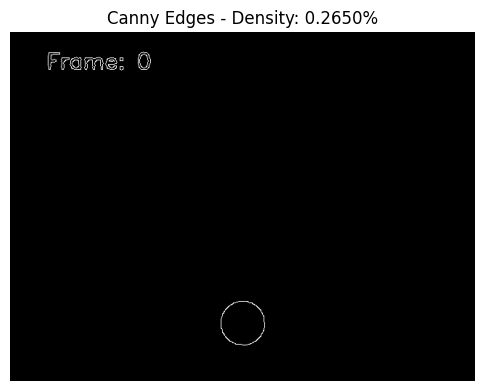

In [6]:
if ret:
    plt.figure(figsize=(6, 6))
    plt.imshow(canny, cmap='gray')
    plt.title(f"Canny Edges - Density: {edge_ratio * 100:.4f}%")
    plt.axis('off')
    plt.show()